In [3]:

import io
import json
import base64
import os
from typing import Any, Dict, List, Tuple
import fitz  # PyMuPDF
import tempfile
import unittest
from typing import Any, Dict, Callable, List
import traceback
import langgraph as lg
import os
import tempfile


In [4]:
import os
from langchain_groq import ChatGroq

groq_api_key = os.getenv('GROQ_API_KEY')
groq_model = "openai/gpt-oss-20b"

llm = ChatGroq(
    groq_api_key=groq_api_key,
    model_name=groq_model,
)

In [ ]:
from langgraph.graph.message import add_messages
from typing import TypedDict, Sequence, Annotated
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [ ]:
from langchain.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage

llm = ChatGroq(model_name="llama-3.3-70b-versatile", temperature=0)
def agent(state):
    messages = state["messages"]
    if len(messages) > 1:
        prompt = PromptTemplate(
            template="""You are a concise assistant. 
Only answer the question directly in one sentence or less.
Question: {question}""",
            input_variables=["question"]
        )
        response = (prompt | llm).invoke({"question": messages[-1].content})
        return {"messages": [AIMessage(content=response.content)]}
    else:
        llm_with_tool = llm.bind_tools(tools)
        response = llm_with_tool.invoke(messages)
        return {"messages": [response]}

In [5]:
# Initialize a Langgraph agent using the existing ChatGroq `llm`.
# This cell tries common langgraph APIs and falls back to a simple wrapper.
groq_agent = None

try:
    Agent = getattr(lg, "Agent", None)
    if Agent is not None:
        # Try common constructor signatures
        try:
            groq_agent = Agent(name="GroqAgent", llm=llm)
        except TypeError:
            try:
                groq_agent = Agent(llm=llm, name="GroqAgent")
            except Exception:
                # attempt other common kwarg names
                for key in ("model", "chat_model", "chat"):
                    try:
                        groq_agent = Agent(**{key: llm, "name": "GroqAgent"})
                        break
                    except Exception:
                        groq_agent = None

    # Try alternative LangGraph class names if direct Agent didn't work
    if groq_agent is None:
        for cls_name in ("ChatAgent", "LLMAgent", "LangChainAgent"):
            cls = getattr(lg, cls_name, None)
            if cls is not None:
                try:
                    groq_agent = cls(llm=llm, name="GroqAgent")
                    break
                except Exception:
                    try:
                        groq_agent = cls(name="GroqAgent", llm=llm)
                        break
                    except Exception:
                        pass
except Exception:
    groq_agent = None

# Final fallback: simple wrapper exposing a run(prompt, **kwargs) method
if groq_agent is None:
    class GroqLangGraphAgent:
        def __init__(self, llm, name="GroqAgent"):
            self.llm = llm
            self.name = name

        def run(self, prompt: str, **kwargs):
            # Try common call patterns for ChatGroq / langchain-style LLMs.
            try:
                return self.llm(prompt, **kwargs)
            except Exception:
                try:
                    # some LLMs expect a list of prompts for generate()
                    gen = getattr(self.llm, "generate", None)
                    if callable(gen):
                        return gen([prompt], **kwargs)
                except Exception:
                    pass
                # as last resort, try a client-facing create call if present
                client = getattr(self.llm, "client", None)
                if client is not None and hasattr(client, "create"):
                    return client.create(prompt)
                raise RuntimeError("Unable to call underlying llm with known patterns.")

    groq_agent = GroqLangGraphAgent(llm=llm)

print("groq_agent initialized:", type(groq_agent).__name__)

groq_agent initialized: GroqLangGraphAgent


In [9]:


# This cell creates two "agents" using langgraph if available (falls back to simple wrappers).
# Agent 1: receives a user prompt and generates text about the topic.
# Agent 2: receives the generated text and writes a PDF using PyMuPDF (fitz).


# --- Helper functions used by the agents ---

def generate_text_from_topic(prompt: str, paragraphs: int = 3) -> str:
    """Generate a simple multi-paragraph text about the given prompt/topic.
    This is a placeholder for an LLM; keep it deterministic and self-contained."""
    prompt = (prompt or "").strip()
    if not prompt:
        prompt = "a generic topic"
    paragraphs = max(1, int(paragraphs))
    body = []
    for i in range(paragraphs):
        body.append(
            f"Paragraph {i+1} about '{prompt}':\n"
            f"This paragraph gives an overview and some details on the topic. "
            f"It elaborates on key points, examples, and practical considerations related to {prompt}."
        )
    return "\n\n".join(body)

def create_pdf_from_text(text: str, filename: str = None, title: str = None) -> str:
    """Create a PDF from the provided text using PyMuPDF and return the saved file path."""
    if filename is None:
        fd, filename = tempfile.mkstemp(suffix=".pdf", prefix="generated_")
        os.close(fd)

    # Split long text into chunks for pages (simple heuristic)
    max_chars_per_page = 2500
    chunks = []
    start = 0
    while start < len(text):
        end = start + max_chars_per_page
        # try to break at newline for nicer pages
        if end < len(text):
            nl = text.rfind("\n", start, end)
            if nl != -1 and nl > start:
                end = nl
        chunks.append(text[start:end].strip())
        start = end

    doc = fitz.open()
    # Optional metadata
    if title:
        doc.set_metadata({"title": title})

    for chunk in chunks:
        page = doc.new_page()  # default size A4-like
        rect = fitz.Rect(72, 72, page.rect.width - 72, page.rect.height - 72)
        # Use a simple textbox insertion; automatic line wrap
        text_options = {
            "fontsize": 11,
            "fontname": "Times-Roman",
            "color": (0, 0, 0),
            "align": 0,  # left
        }
        page.insert_textbox(rect, chunk, **text_options)

    # Ensure directory exists
    os.makedirs(os.path.dirname(filename) or ".", exist_ok=True)
    doc.save(filename)
    doc.close()
    return filename

# --- Agent wrappers (use langgraph's Agent if present; otherwise use simple wrapper) ---

try:
    AgentClass = lg.Agent  # try to use langgraph Agent if available
except Exception:
    class AgentClass:
        def __init__(self, name: str, func):
            self.name = name
            self.func = func

        def run(self, *args, **kwargs):
            return self.func(*args, **kwargs)

# Create agent instances
text_agent = AgentClass(name="TextGenerator", func=generate_text_from_topic)
pdf_agent = AgentClass(name="PDFCreator", func=create_pdf_from_text)

# If langgraph provides a Graph/Flow API, demonstrate wiring the two agents into a graph (best-effort)
graph = None
try:
    if hasattr(lg, "Graph"):
        graph = lg.Graph(name="TextToPdfGraph")
        # Attempt to add/wire nodes using commonly used method names; ignore errors if API differs
        try:
            g_text = graph.add_agent(text_agent) if hasattr(graph, "add_agent") else graph.add_node(text_agent)
            g_pdf = graph.add_agent(pdf_agent) if hasattr(graph, "add_agent") else graph.add_node(pdf_agent)
            # try connecting common patterns
            if hasattr(graph, "connect"):
                graph.connect(g_text, g_pdf, output_key="text", input_key="text")
        except Exception:
            # If Graph API differs, ignore and fall back to manual invocation below
            pass
except Exception:
    graph = None

# --- Example usage (call these in notebook cells or adapt to user input) ---
# Example: run the pipeline for a user prompt and save to a file.
user_prompt = "sustainable urban gardening"
generated_text = getattr(text_agent, "run")(user_prompt, paragraphs=4)
output_pdf_path = getattr(pdf_agent, "run")(generated_text, filename="sustainable_urban_gardening.pdf", title=user_prompt)

print("Generated text (truncated):")
print(generated_text[:500] + ("..." if len(generated_text) > 500 else ""))
print(f"PDF created at: {output_pdf_path}")

NameError: name 'fitz' is not defined

In [1]:
import os
from typing import Dict, TypedDict,List
from langchain_groq import ChatGroq
from langchain.schema import BaseMessage
from langgraph.graph import StateGraph, END

# Set up the Groq LLM
llm = ChatGroq(
        model_name="llama-3.1-70b-versatile",
        temperature=0.1,
        model_kwargs={"top_p": 0.5, "seed": 1337}
    )
# Define our state structure
class State(TypedDict):
    messages: List[BaseMessage]
    next_step: str

workflow = StateGraph(State)    

In [ ]:
# Add two new nodes to the existing StateGraph: one to generate multi-paragraph text
# from the user's topic, and one to render that generated text to a PDF.
# Overwrite the existing `get_name` node to route the flow into the new nodes,
# then recompile the graph into `app`.

def greet(state: State) -> State:
    state["messages"].append({"role": "assistant", "content": "Hello! What is the topic you would like to create pdf from?"})
    state["next_step"] = "get_name"
    return state


def _find_last_message_of_role(state: State, role: str) -> str:
    for m in reversed(state.get("messages", [])):
        if m.get("role") == role:
            return m.get("content", "")
    return ""

def new_get_name(state: State) -> State:
    """Treat the incoming human message (prompted by greet) as the topic,
    acknowledge, and move to the generate_text node."""
    topic = _find_last_message_of_role(state, "human")
    state["messages"].append({"role": "assistant", "content": f"Great — generating content about: '{topic}'."})
    state["next_step"] = "generate_text"
    return state

def generate_text_node(state: State) -> State:
    """Generate a multi-paragraph text for the topic found in the most recent human message."""
    topic = _find_last_message_of_role(state, "human")
    # Use existing helper if present; fallback to a simple deterministic generator.
    gen_fn = globals().get("generate_text_from_topic")
    if callable(gen_fn):
        generated = gen_fn(topic, paragraphs=4)
    else:
        # fallback deterministic generator
        if not topic:
            topic = "a generic topic"
        paragraphs = 4
        parts = []
        for i in range(paragraphs):
            parts.append(
                f"Paragraph {i+1} about '{topic}':\nThis paragraph covers details and practical considerations regarding {topic}."
            )
        generated = "\n\n".join(parts)

    state["messages"].append({"role": "assistant", "content": generated})
    state["next_step"] = "create_pdf"
    return state

def create_pdf_node(state: State) -> State:
    """Create a PDF from the last assistant message (the generated text) and report the file path."""
    topic = _find_last_message_of_role(state, "human")
    text = _find_last_message_of_role(state, "assistant")
    # make a safe short filename from the topic
    safe = "".join(c if c.isalnum() else "_" for c in (topic or "output"))[:60].rstrip("_") or "output"
    filename = f"{safe}.pdf"

    create_fn = globals().get("create_pdf_from_text")
    if callable(create_fn):
        try:
            path = create_fn(text, filename=filename, title=topic or None)
        except Exception as e:
            state["messages"].append({"role": "assistant", "content": f"Failed to create PDF: {e}"})
            state["next_step"] = END
            return state
    else:
        # If helper not present, write a simple text-file fallback
        path = filename.replace(".pdf", ".txt")
        with open(path, "w", encoding="utf-8") as f:
            f.write(text or "")
    state["messages"].append({"role": "assistant", "content": f"PDF created at: {path}"})
    state["next_step"] = END
    return state

# Replace / add nodes in the workflow graph and wire edges, then recompile.
workflow.add_node("greet", greet)
workflow.add_node("get_name", new_get_name)            # overwrite existing behavior to continue to generate_text
workflow.add_node("generate_text", generate_text_node)
workflow.add_node("create_pdf", create_pdf_node)

# Wire the new sequence: after get_name -> generate_text -> create_pdf -> END
workflow.set_entry_point("greet")
workflow.add_edge("greet", "get_name")
workflow.add_edge("get_name", "generate_text")
workflow.add_edge("generate_text", "create_pdf")
workflow.add_edge("create_pdf", END)



In [6]:
# Recompile the graph so `app` reflects the new nodes
app = workflow.compile()
print("Added 'generate_text' and 'create_pdf' nodes and recompiled the graph into `app`.")

Added 'generate_text' and 'create_pdf' nodes and recompiled the graph into `app`.


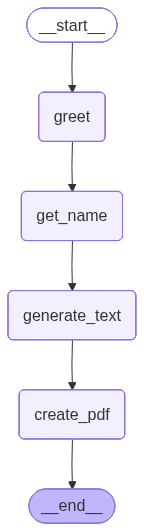

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
# Initialize the state
initial_state = {"messages": [],"next_step":""}
# Run the graph
for event in app.stream(initial_state):
    for output in event.values():
        if "messages" in output:
            for message in output["messages"]:
                if message["role"] == "assistant":
                    print(f"Assistant: {message['content']}")
                elif message["role"] == "human":
                    print(f"Human: {message['content']}")
    
    # Check if 'next_step' exists
    if "next_step" in output and output["next_step"] == "get_name":
        user_input = input("Your response: ")
        output["messages"].append({"role": "human", "content": user_input})

print("Conversation ended.")

Assistant: Hello! What is the topic you would like to create pdf from?
Assistant: Hello! What is the topic you would like to create pdf from?
Human: turtles
Assistant: Great — generating content about: 'turtles'.
Assistant: Hello! What is the topic you would like to create pdf from?
Human: turtles
Assistant: Great — generating content about: 'turtles'.
Assistant: Paragraph 1 about 'turtles':
This paragraph covers details and practical considerations regarding turtles.

Paragraph 2 about 'turtles':
This paragraph covers details and practical considerations regarding turtles.

Paragraph 3 about 'turtles':
This paragraph covers details and practical considerations regarding turtles.

Paragraph 4 about 'turtles':
This paragraph covers details and practical considerations regarding turtles.
Assistant: Hello! What is the topic you would like to create pdf from?
Human: turtles
Assistant: Great — generating content about: 'turtles'.
Assistant: Paragraph 1 about 'turtles':
This paragraph covers